In [59]:
# Import all packages and relevant functions
import matplotlib.pyplot as plt
import numpy as np
import os
import dill as pickle
from sklearn.feature_selection import mutual_info_regression
from scipy.interpolate import make_smoothing_spline

# Import fns_plotting_scripts
import fns_plotting_scripts as fns_plot

In [73]:
# Define dataset and subset of conditions to be analyzed
mode_expt = 0
if mode_expt == 1:
    directory = 'data_expt_X10_scaled_bgsub'
    conditions = ['B50']#['B10','B50','B200']
elif mode_expt == 2:
    directory = 'data_expt_X7_scaled_bgsub'
    conditions = ['B50']#, 'B50T30'
else:
    directory = 'data_expt_20_scaled_bgsub_norm'
    conditions = ['B50']
    use_scaled = 1

# Define subdirectory to save plots to + take data from
subdirectory_plot = directory + '/analysis_poserror_intra'
if not os.path.exists(subdirectory_plot):
    os.mkdir(subdirectory_plot)
subdirectory_data = directory + '/data'


# Define parameters for figure plotting
file_suffix = '.png'
plt.close("all")

fig_size = [6,3]     
params = {
          'figure.figsize': fig_size,
          }
label_fontsize = 40
tick_fontsize = 35
cell_diam = 10 # cell diameter in microns
plt.rcParams.update(params)

plt.rcParams['axes.linewidth'] = 5
H,W = 1,3 #height and width of subplots
plt.rcParams['font.weight'] = 'normal'
weight = "normal"

# option for bold labels, ticks, and legends
is_bold = False
if is_bold:
    plt.rcParams['font.weight'] = 'bold'
    weight = "bold"

In [84]:
# Iterate through each condition in the dataset
N_radial_bins_raw = 20
N_radial_bins_smoothed = 50
N_conds = len(conditions)

for it_cond,cond in enumerate(conditions):
    # Load the data from the .pickle file
    if use_scaled:
        f = open(subdirectory_data + '/data_' + cond + "_scaled.pickle",'rb')
        data = pickle.load(f)
        f.close()
    else:
        f = open(subdirectory_data + '/data_' + cond + ".pickle",'rb')
        data = pickle.load(f)
        f.close()

    # Defines a colormap where each color corresponds to a colony
    colors = fns_plot.return_colmaps('replicates',data.N_sys)

    # Choose whether we're using signaling data or marker gene data
    for mode_signals in [1]:
        
        if mode_signals == 1:
            suffix = '_signals'
            data_here = data.signals
            N_var = data.N_signals
            if use_scaled:
                names = ['pERK', 'pSMAD1', 'β-catenin', 'LEF1', 'SMAD2/3', 'YAP', 'pAKT']
                sample_list = ['pSMAD1', 'YAP', 'β-catenin', 'LEF1', 'SMAD2/3', 'pERK', 'pAKT']
            else:
                names = data.signal_names
                sample_list = names
            sig_or_gene = "pSMAD1"
            reg_term = 0.002
            # current_version: reg_term = 0
        else:
            suffix = '_genes'
            data_here = data.genes
            N_var = data.N_genes
            names = data.gene_names
            sample_list = ['GATA3', 'CDX2', 'NANOG', 'TBXT', 'OCT4', 'SOX2'] 
            sig_or_gene = "SOX2"
            reg_term = 0.002
            # current_version: reg_term = 0.00625


        # Define numbers of bins for 1) initial computation of radial profiles and 
        # 2) smoothed interpolated radial profiles
        N_radial_bins_raw = 20
        N_radial_bins_smoothed = 50
        
        # Iterate through all signals/genes and compute individual positional error
        all_pos_error_single = np.zeros((N_var, N_radial_bins_smoothed-1))
        all_pos_error_single_raw = np.zeros((N_var, N_radial_bins_raw-1))
        all_radial_profiles = np.zeros((N_var, N_radial_bins_smoothed))
        all_variances = np.zeros((N_var, N_radial_bins_smoothed))
        for k in range(0, N_var):
            data_k= data_here[:,:,k][:,:,np.newaxis]
            edge_dist = data.metricdist
            radial_bins_smoothed, avg_radial_profile_smoothed, var_radial_profile_smoothed, pos_error_smoothed ,radial_bins_smoothed_sym, _ = fns_plot.calc_poserror_smooth(data_k, edge_dist, N_radial_bins_raw,data.r_max, reg_term, N_bins_x = N_radial_bins_smoothed)
            all_pos_error_single[k, :] = pos_error_smoothed
            all_radial_profiles[k, :] = avg_radial_profile_smoothed.flatten()
            all_variances[k, :] = var_radial_profile_smoothed.flatten()

In [87]:
# Isolate signal or gene of choice
k = names.index(sig_or_gene)
sig_or_gene_all_colonies = data_here[:,:,k][:,:,np.newaxis]
sig_or_gene_avg_profile = all_radial_profiles[k, :]
sig_or_gene_var_profile = all_variances[k, :]

In [90]:
# Concatenate relevant data
data_metricdist_all = data.metricdist[0, :]
data_here_all = data_here[0,:,k]
color_all = [colors[0] for i in range(len(data_here_all))]

for i in range(1, data.N_sys):
    data_metricdist_all = np.concatenate((data_metricdist_all, data.metricdist[i, :]))
    data_here_all = np.concatenate((data_here_all, data_here[i, :, k]))
    color_all = np.concatenate((color_all, [colors[i] for j in range(len(data_here[i, :, k]))]))

In [91]:
# Random
randomized_indices = np.random.permutation(np.arange(len(data_metricdist_all)))

In [92]:
data_metricdist_all_shuffled = data_metricdist_all[randomized_indices]
data_here_all_shuffled = data_here_all[randomized_indices]
color_all_shuffled = color_all[randomized_indices, :]

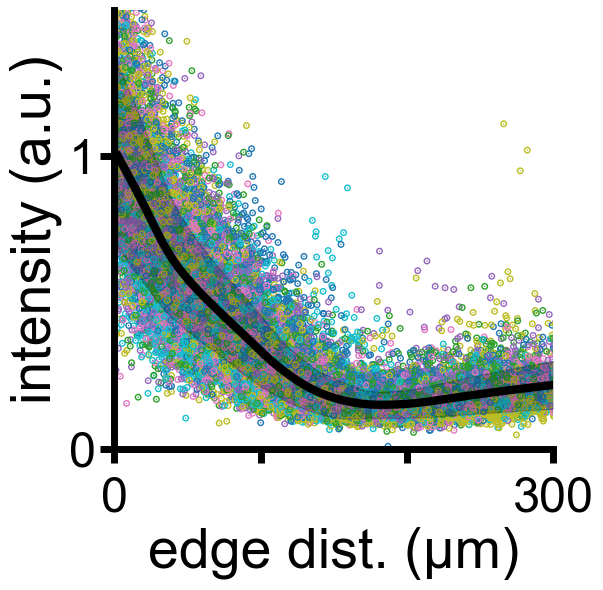

In [93]:
plt.figure(figsize = (7, 6))              
ax = plt.gca()
# Plot all data points for SOX2 + average SOX2 profile across the data

plt.scatter(data_metricdist_all_shuffled, data_here_all_shuffled, 1,color= color_all_shuffled,lw=4)
plt.plot(radial_bins_smoothed, SOX2_avg_profile,'-k',lw=6)


# Add gray error bar
plt.fill_between(radial_bins_smoothed, SOX2_avg_profile-np.sqrt(SOX2_var_profile), SOX2_avg_profile+np.sqrt(SOX2_var_profile),color='k',alpha=0.2)
ax.set_xticks(ticks = np.arange(0, 301, step=100), labels = [0, "", "", 300], fontsize=tick_fontsize , fontweight = weight, family='Arial') 
#ax.set_yticks(ticks = np.arange(0, 1.6, step=1), labels = np.arange(0, 1.6, step=0.5), fontsize = tick_fontsize, fontweight = weight, family='Arial')
ax.set_yticks(ticks = np.arange(0, 6, step=1), labels = np.arange(0, 6, step=1), fontsize = tick_fontsize, fontweight = weight, family='Arial')

# x and y labels
plt.xlabel('edge dist. (μm)', fontsize = label_fontsize, fontweight = weight, family='Arial')
plt.ylabel('intensity (a.u.)', fontsize = label_fontsize,fontweight = weight,  family='Arial')

# Set x and y limits
ax.set(xlim = (0,300), ylim = (0, 1.5))


# Make plot square
plt.gca().set_box_aspect(1)


# Make right and top bounding boxes invisible
plt.gca().spines['right'].set_linewidth(0)
plt.gca().spines['top'].set_linewidth(0)

# Adjust ticks
plt.gca().tick_params(axis='both', which='major', width=5, length=10)
ax.tick_params(axis = 'y', which = 'major',labelsize=tick_fontsize , width=5, length=10)
ax.tick_params(axis = 'x', which = 'major',labelsize=tick_fontsize , width=5, length=10, pad=10)

plt.tight_layout()
#plt.savefig(subdirectory_plot + "/" + 'radialprofile' + suffix +'_' + cond + '_' + sig_or_gene)

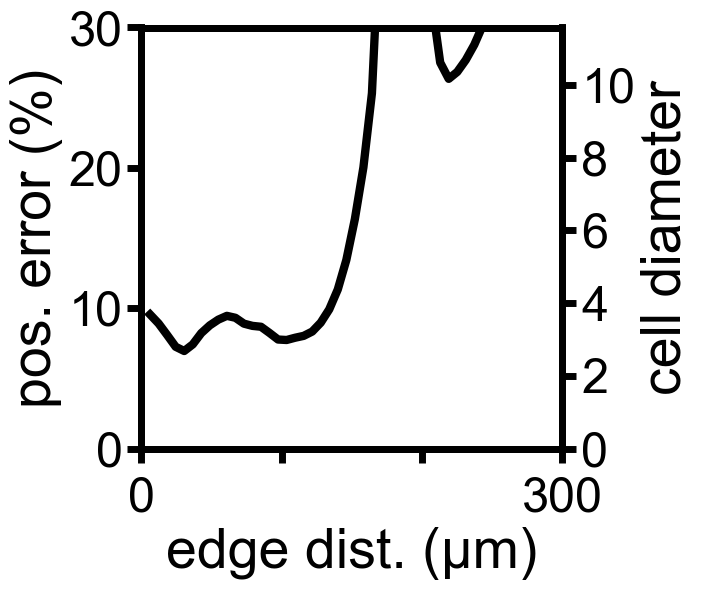

In [72]:
# Plot of Figure 2F (intra-positional error of SOX2 + S0X2 pos. error of individual
# colonies)

SOX2_intra_pos_error = all_pos_error_single[k, :]

plt.figure(figsize = (7, 6))
ax = plt.gca()

# Plot S0X2 positional error normalized by maximum radius for each individual colonies
for it in range(0,data.N_sys):
    data_SOX2_it = data_here[it,:,k][np.newaxis,:,np.newaxis]
    edge_dist_it = data.metricdist[it,:][np.newaxis,:]
    _,_,_,pos_error_it,radial_bins_smoothed_sym,_ = fns_plot.calc_poserror_smooth(data_SOX2_it,edge_dist_it,N_radial_bins_raw,data.r_max, reg_term, N_bins_x = N_radial_bins_smoothed)
    #plt.plot(radial_bins_smoothed_sym,pos_error_it/data.r_max,color=colors[it],lw=6,alpha=0.5)
    
# Plot S0X2 positional error normalized by maximum radius
plt.plot(radial_bins_smoothed_sym, SOX2_intra_pos_error/data.r_max,color='k',lw=6)

# x and y labels
plt.xlabel('edge dist. (μm)', fontsize = label_fontsize, fontweight = weight, family='Arial')
plt.ylabel('pos. error (%)', fontsize = label_fontsize, fontweight = weight, family='Arial')

ax.set_xticks(ticks = np.arange(0, 301, step=100), labels = [0, "", "", 300], fontsize = tick_fontsize ,  family='Arial') 
ax.set_yticks(ticks = np.arange(0, 0.31, step=0.1), labels = np.arange(0, 31, step=10), fontsize = tick_fontsize ,  family='Arial')


# Add second y-axis to link positional error to number of cell diameters
ax2 = ax.twinx()
ax2.set_ylabel("cell diameter", fontsize = label_fontsize, fontweight = weight, family='Arial')
ax2.set_yticks(ticks = np.arange(0, 0.3 + cell_diam/data.r_max, step=2*cell_diam/data.r_max), labels = np.arange(0, 12, step=2) , fontsize = tick_fontsize , family='Arial')

# Set x and y limits
ax.set(xlim = (0,300), ylim = (0, 0.3))
ax2.set(ylim = (0, 0.32))

# Make plot square
ax.set_box_aspect(1)

# Adjust ticks
ax.tick_params(axis = 'y', which = 'major',labelsize=tick_fontsize  , width=5, length=10)
ax.tick_params(axis = 'x', which = 'major',labelsize=tick_fontsize  , width=5, length=10, pad=10)
ax2.tick_params(axis = 'both', which = 'major',labelsize=tick_fontsize  , width=5, length=10)


plt.tight_layout()
plt.savefig(subdirectory_plot + "/" + 'poserror' + suffix +'_' + cond + '_' + sig_or_gene)